In [1]:
import pandas as pd
data = pd.read_csv('AB_NYC_2019.csv')
data


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [3]:
	data.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [7]:

# Fill missing names with 'Unknown'
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

#This removes every row where last_review is NaN
df.dropna(subset=['last_review'], inplace=True)

# Fill missing numeric review data with 0  since it has to do with ratings
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)   # missing review means there were no reviews for that month, filling it as zero is the ebst

# Re-checking the number of null values
print(df.isnull().sum())


id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


In [8]:
#checking for duplicates in the data
print(df.duplicated().sum())


0


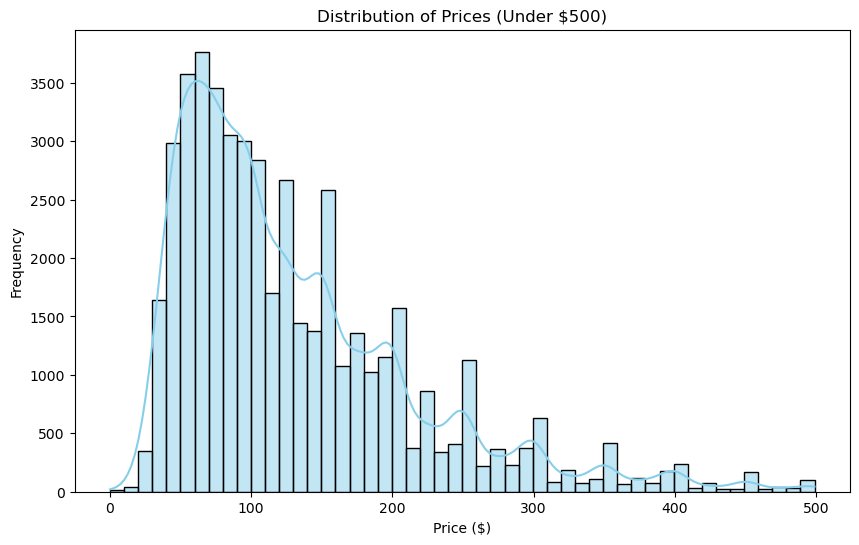

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt


#This shows you the "spread" of prices. Since Airbnb data usually has a few very expensive listings (outliers), we limit the x-axis to 500 to see the most common prices clearly.

plt.figure(figsize=(10, 6))
sns.histplot(data[data['price'] < 500]['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Prices (Under $500)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()


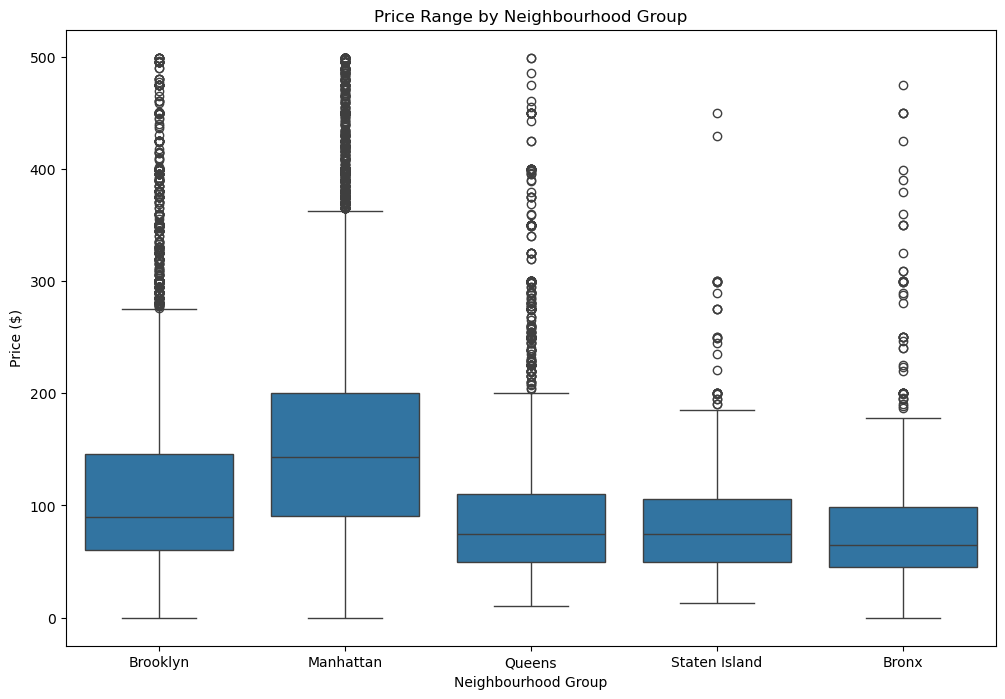

In [4]:
#This is perfect for comparing different areas (like Manhattan vs. Brooklyn). It shows the median price and the range for each borough.
# it shows different options with similar price

plt.figure(figsize=(12, 8))
sns.boxplot(x='neighbourhood_group', y='price', data=data[data['price'] < 500])
plt.title('Price Range by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Price ($)')
plt.show()


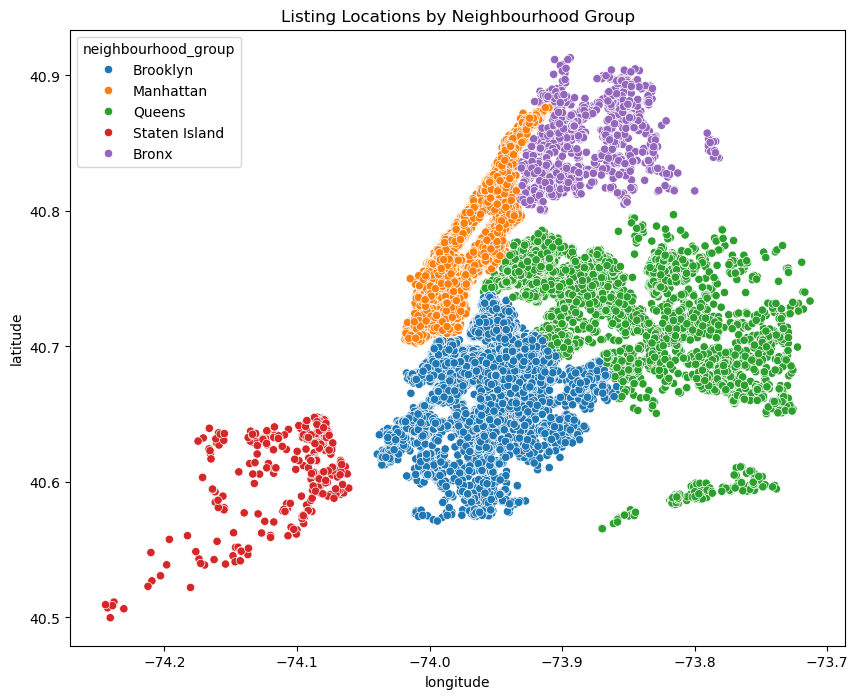

In [8]:
# Drawing the city map based on price helps to easily see a particular area with price
plt.figure(figsize=(10, 8))
sns.scatterplot(x='longitude', y='latitude', hue='neighbourhood_group', data=data)
plt.title('Listing Locations by Neighbourhood Group')
plt.show()

